## VBE Style Modular Exponentiation

- https://arxiv.org/pdf/2306.09122
- https://arxiv.org/pdf/quant-ph/9511018

In [66]:
# !pip install qiskit_aer
%matplotlib inline

import sys
sys.path.append("../src")

from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from mod_adder_vbe import mod_adder_vbe
from mod_mult_vbe import mod_mult_vbe
from qiskit import transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import math
from qiskit.synthesis.qft import synth_qft_full
from utils import reduce_to_minimal_period, estimate_r_from_bitstring, factors_from_r
from datetime import datetime
from fractions import Fraction

In [37]:
def required_m(N):
    return math.ceil(2 * math.log2(N))

### Example (N=21, a=2)

To factor an integer $N=21$ we are looking for the r so that $2^{r} \equiv 1 \pmod{21}$. Therefore we need sufficient resolution, which requires roughtly $m>2\log_{2}N$ or $m>9$ control qubits. For this example $r=6$, therefore we are looking for phases such as $\theta=\frac{k}{r}=\frac{k}{6}$

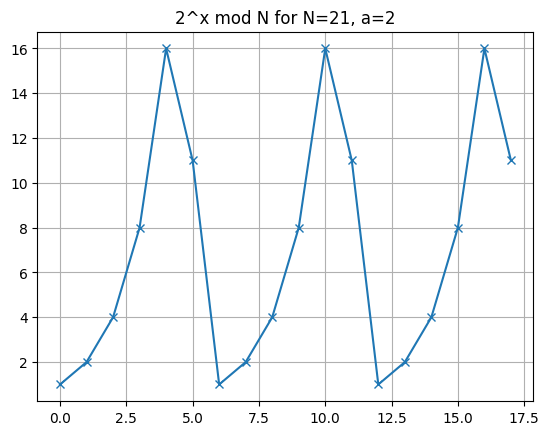

In [51]:
plt.plot(range(18), [pow(2, x, 21) for x in range(18)], "-x")
plt.title("2^x mod N for N=21, a=2")
plt.grid()
plt.show()

In [38]:
print("Required qubits: ", required_m(21))

Required qubits:  9


In [73]:
tests = [
    (15, 8),   # r=6, N=5*3
    (21, 2),   # r=6, N=3*7, eigenphases = s/r, where s={0, 1, 2, 3, 4, 5}
    (33, 7),   # r=10, N=11*3
    (35, 4),   # r=6
    (143, 5),  # r=20
    (247, 2),  # r=36, N=13*19
    (341, 3),  # r=10, N=11*31
    (437, 2),  # r=198, N=19*23
    (589, 3),  # r=90, N=19*31
    (899, 2)   # r=140, N=29*31
]

test = 1

N_val = tests[test][0]
a_val = tests[test][1]

n = math.ceil(math.log2(N_val + 1))
m = n + 1

control_qubits = 9

ctrl = QuantumRegister(control_qubits, "ctrl")
a = QuantumRegister(m, 'a') 
b = QuantumRegister(m, 'b')
c = QuantumRegister(1, 'c')
N = QuantumRegister(m, 'N')
t = QuantumRegister(1, 't')
y = QuantumRegister(m, 'y')
creg = ClassicalRegister(len(ctrl), 'creg')

qc = QuantumCircuit(ctrl, a, b, c, N, t, y, creg)

# load modular adder
mod_add = mod_adder_vbe(m, N_val)

# prepare N
for i in range(m):
    if (N_val >> i) & 1:
        qc.x(N[i])

# prepare y in 1
qc.x(y[0])

# activate control
for i in range(control_qubits):
    qc.h(ctrl[i])

for i in range(control_qubits):
    k = pow(a_val, 1 << i, N_val) # a^(2^i) mod N

    mod_mult = mod_mult_vbe(m, k, N_val, mod_add)
    qc.append(mod_mult, [ctrl[i]] + a[:] + b[:] + c[:] + N[:] + [t[0]] + y[:])

qc.barrier()

# build IQFT with swaps
iqft = synth_qft_full(num_qubits=control_qubits, do_swaps=True).inverse()
qc.compose(iqft, qubits=list(ctrl)[:control_qubits], inplace=True)

qc.barrier()

# measure circuit
qc_measure = qc.copy()
qc_measure.measure(ctrl, creg)

start = datetime.now()
print(f"Start: {start}")

sim = AerSimulator(method="matrix_product_state")
tqc = transpile(qc_measure, sim)

nbr_shots = 2**12
result = sim.run(tqc, shots=nbr_shots).result()
counts = result.get_counts()

end = datetime.now()
print(f"End:   {end}")

runtime = end - start
print(f"Runtime: {runtime}")

Start: 2026-06-02 00:15:52.952072
End:   2026-06-02 00:17:00.533293
Runtime: 0:01:07.581221


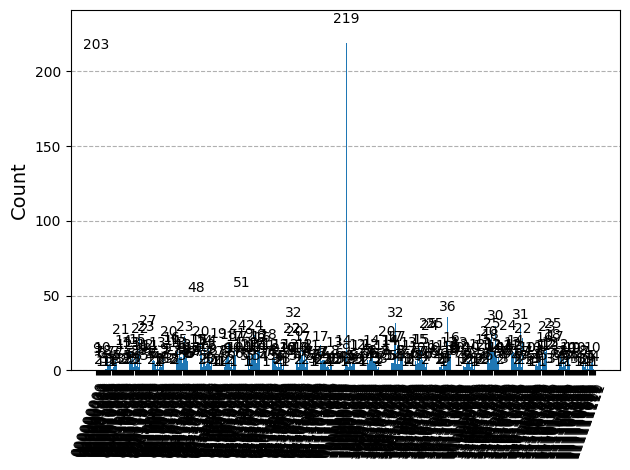

In [74]:
plot_histogram(counts)

In [81]:
sorted_outcomes = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)

estimates = []
for bitstr, c in sorted_outcomes:
    est = estimate_r_from_bitstring(bitstr, m=control_qubits, a=a_val, N=N_val)
    estimates.append((bitstr, c, est))
    
for bitstring, c, est in estimates:
    print(f"bitstring={bitstr}, count={c}, y={est['y']}, theta={est['theta']:.4f}, frac={est['frac']}, r0={est['r0']}, r={est['r']}")

for bitstr, c, est in estimates:
    r = est['r']
    r = reduce_to_minimal_period(a_val, N_val, r)
    p, q = factors_from_r(a_val, N_val, r)
    if p and q:
        print(f"Using bitstr {bitstr} -> r={r}, factors: {p}, {q}")
        break

bitstring=000001010, count=219, y=256, theta=0.5000, frac=1/2, r0=2, r=6
bitstring=000001010, count=203, y=0, theta=0.0000, frac=0, r0=1, r=6
bitstring=000001010, count=51, y=154, theta=0.3008, frac=3/10, r0=10, r=30
bitstring=000001010, count=48, y=102, theta=0.1992, frac=1/5, r0=5, r=30
bitstring=000001010, count=36, y=358, theta=0.6992, frac=7/10, r0=10, r=30
bitstring=000001010, count=32, y=205, theta=0.4004, frac=2/5, r0=5, r=30
bitstring=000001010, count=32, y=307, theta=0.5996, frac=3/5, r0=5, r=30
bitstring=000001010, count=31, y=435, theta=0.8496, frac=17/20, r0=20, r=60
bitstring=000001010, count=30, y=410, theta=0.8008, frac=4/5, r0=5, r=30
bitstring=000001010, count=27, y=53, theta=0.1035, frac=2/19, r0=19, r=114
bitstring=000001010, count=25, y=339, theta=0.6621, frac=2/3, r0=3, r=6
bitstring=000001010, count=25, y=467, theta=0.9121, frac=10/11, r0=11, r=66
bitstring=000001010, count=25, y=406, theta=0.7930, frac=15/19, r0=19, r=114
bitstring=000001010, count=25, y=346, th

In [83]:
# example y=32
y = 256
theta = y / 2**control_qubits
theta

0.5

In [93]:
max_den = N_val
frac = Fraction(theta).limit_denominator(max_den)   
s, r0 = frac.numerator, frac.denominator
print("frac: ", frac)
print("r0: ", r0)

frac:  1/2
r0:  2


In [91]:
r = None
for k in range(1, control_qubits*N_val):
    cand = r0 * k
    if pow(a_val, cand, N_val) == 1:
        r = cand
        break

print(r)

6


In [95]:
# check
pow(a_val, r, N_val)

1

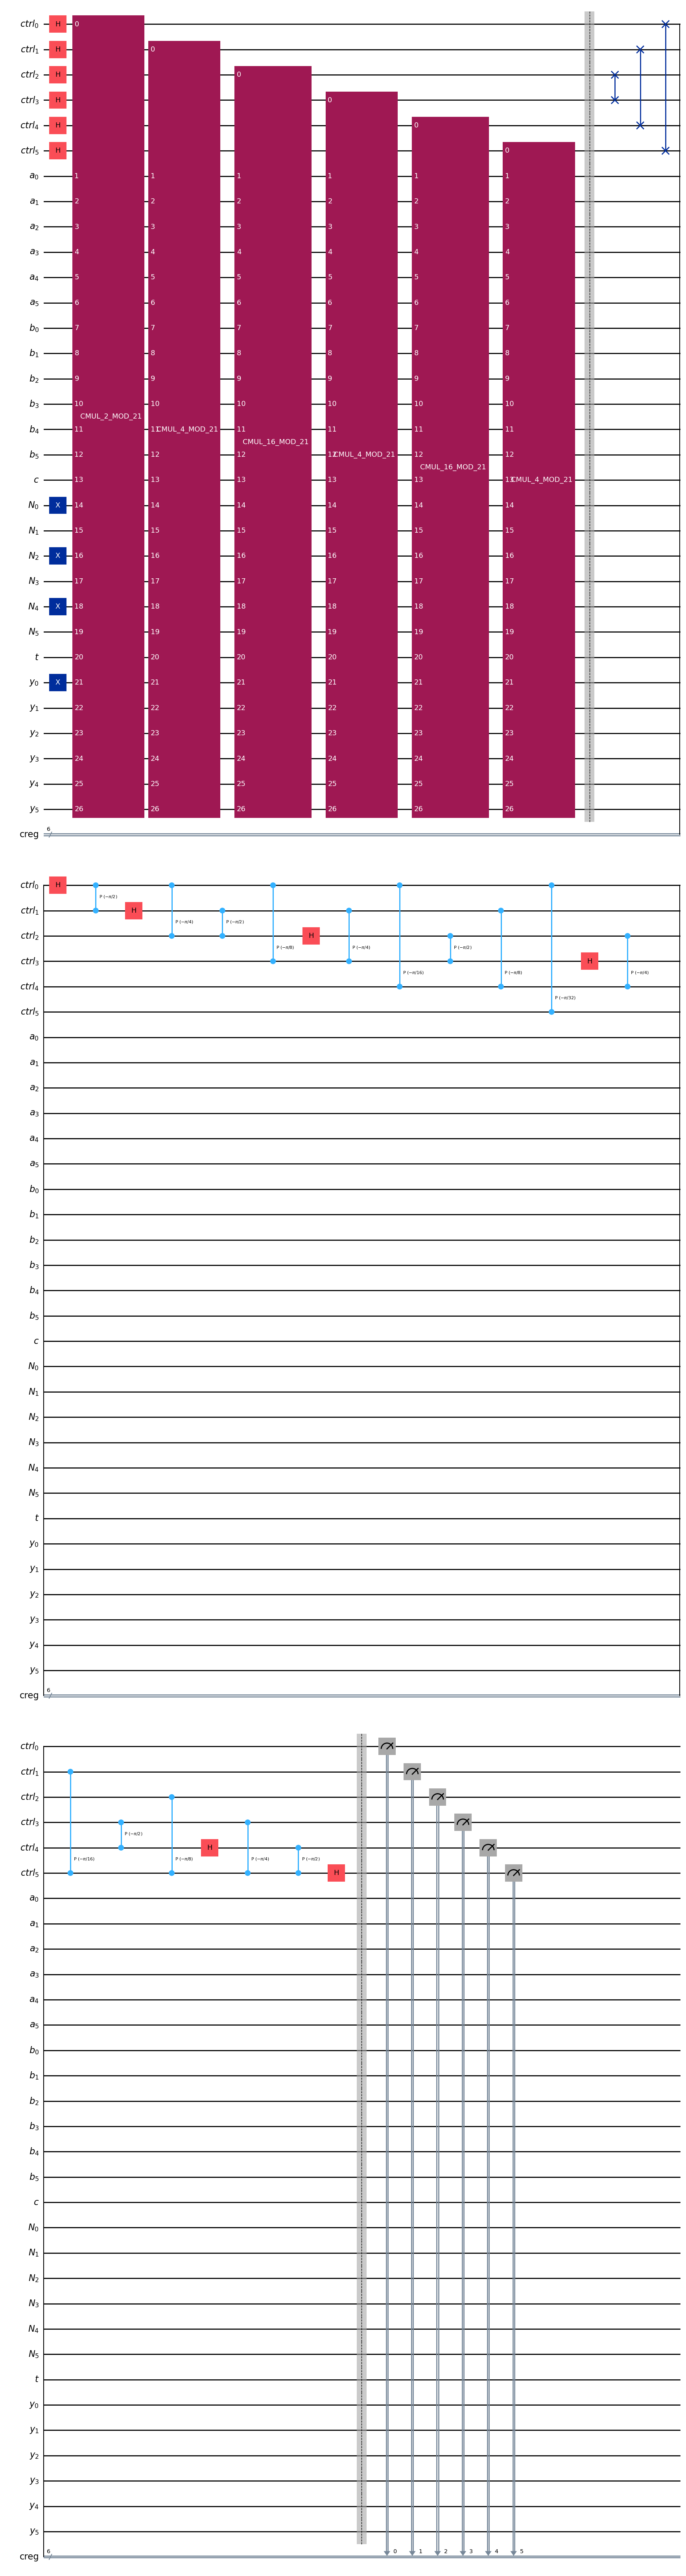

In [59]:
qc_measure.draw('mpl')